<a href="https://colab.research.google.com/github/prajwalbhandari416/Geomagnetic-Storms/blob/main/Final_Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
Geomagnetic Storm Prediction using Deep Learning

Author: Prajwal Bhandari
Date: January 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
!pip install tensorflow
!pip install keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                      Conv1D, MaxPooling1D, Flatten, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


In [ ]:
# -----------------------------
# 1. DATA LOADING AND PREPROCESSING
# -----------------------------

class DataPreprocessor:
    """Handles all data preprocessing operations"""

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None
        self.scaler = MinMaxScaler()
        self.missing_values_map = {
            'B': 9999.99,
            'Bx': 9999.99,
            'By': 9999.99,
            'Bz': 9999.99,
            'Vt': 99999.9,
            'FP': 999.99,
            'Kpt': 9.99,
            'AE': 9999.99
        }

    def load_data(self):
        self.df = pd.read_csv(self.filepath)
        print(f"Dataset Shape: {self.df.shape}")
        print(f"\nColumns: {list(self.df.columns)}")
        print(f"\nFirst few rows:\n{self.df.head()}")

        return self

    def handle_missing_values(self):
        # Replace placeholder values
        for col, missing_val in self.missing_values_map.items():
            if col in self.df.columns:
                count_before = (self.df[col] == missing_val).sum()
                self.df[col] = self.df[col].replace(missing_val, np.nan)
                print(f"{col}: Replaced {count_before} placeholder values")

        # Display missing value statistics
        missing_stats = self.df.isnull().sum().sort_values(ascending=False)
        missing_pct = (missing_stats / len(self.df) * 100).round(2)

        print(f"\nMissing Values Summary:")
        for col in missing_stats[missing_stats > 0].index:
            print(f"  {col}: {missing_stats[col]} ({missing_pct[col]}%)")

        return self

    def clean_data(self, target_column='Dst'):
        # Handle time column
        if 'Time' in self.df.columns:
            self.df['Time'] = pd.to_datetime(self.df['Time'], errors='coerce')
            self.df = self.df.sort_values('Time')
            self.df = self.df.drop(columns=['Time'])

        # Convert all columns to numeric
        for col in self.df.columns:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Forward fill then backward fill missing values
        self.df = self.df.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        initial_shape = self.df.shape[0]
        self.df = self.df.dropna()
        dropped_rows = initial_shape - self.df.shape[0]

        print(f"Rows dropped: {dropped_rows}")
        print(f"Final dataset shape: {self.df.shape}")
        print(f"\nData types:\n{self.df.dtypes}")

        return self

    def get_processed_data(self):
        """Return processed dataframe"""
        return self.df


# -----------------------------
# 2. SEQUENCE GENERATION
# -----------------------------

class SequenceGenerator:
    """Creates sequences for time series prediction"""

    def __init__(self, data, target_column='Dst', lookback=48):
        self.data = data
        self.target_column = target_column
        self.lookback = lookback
        self.scaler = MinMaxScaler()

    def create_sequences(self):
        """Create input-output sequences"""
        print("\n" + "=" * 70)
        print("CREATING SEQUENCES")
        print("=" * 70)

        # Scale the data
        scaled_data = self.scaler.fit_transform(self.data)
        target_index = self.data.columns.get_loc(self.target_column)

        X, y = [], []
        for i in range(len(scaled_data) - self.lookback):
            X.append(scaled_data[i:i + self.lookback])
            y.append(scaled_data[i + self.lookback, target_index])

        X = np.array(X)
        y = np.array(y)

        print(f"Sequence shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Features: {X.shape[2]}")
        print(f"Lookback: {self.lookback} hours")

        return X, y

    def split_data(self, X, y, test_size=0.2, val_size=0.15):
        # First split: train+val and test
        split_idx = int(len(X) * (1 - test_size))
        X_temp, X_test = X[:split_idx], X[split_idx:]
        y_temp, y_test = y[:split_idx], y[split_idx:]

        # Second split: train and validation
        val_split_idx = int(len(X_temp) * (1 - val_size / (1 - test_size)))
        X_train, X_val = X_temp[:val_split_idx], X_temp[val_split_idx:]
        y_train, y_val = y_temp[:val_split_idx], y_temp[val_split_idx:]

        print(f"Train set: {X_train.shape[0]} samples")
        print(f"Validation set: {X_val.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")

        return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
# -----------------------------
# 3. MODEL ARCHITECTURES
# -----------------------------

class ModelFactory:
    """Factory for creating different model architectures"""

    @staticmethod
    def build_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Standard LSTM model"""
        model = Sequential([
            LSTM(units[0], return_sequences=True, input_shape=input_shape),
            Dropout(dropout),
            LSTM(units[1]),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_bidirectional_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Bidirectional LSTM - captures patterns in both directions"""
        model = Sequential([
            Bidirectional(LSTM(units[0], return_sequences=True), input_shape=input_shape),
            Dropout(dropout),
            Bidirectional(LSTM(units[1])),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=50, dropout=0.2):
        """CNN-LSTM Hybrid - CNNs extract features, LSTM captures temporal dependencies"""
        model = Sequential([
            Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
                   input_shape=input_shape, padding='same'),
            MaxPooling1D(pool_size=2),
            Dropout(dropout),
            LSTM(lstm_units, return_sequences=True),
            Dropout(dropout),
            LSTM(lstm_units // 2),
            Dropout(dropout),
            Dense(1)
        ])
        return model


    @staticmethod
    def build_tcn(input_shape, nb_filters=64, kernel_size=3, nb_stacks=1,
                  dilations=[1, 2, 4, 8], dropout=0.2):
        """Temporal Convolutional Network - uses dilated convolutions"""
        inputs = Input(shape=input_shape)
        x = inputs

        for stack in range(nb_stacks):
            for dilation in dilations:
                # Residual block
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(x)
                conv = Dropout(dropout)(conv)
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(conv)
                conv = Dropout(dropout)(conv)

                # Match dimensions if needed
                if x.shape[-1] != nb_filters:
                    x = Conv1D(filters=nb_filters, kernel_size=1, padding='same')(x)

                x = tf.keras.layers.Add()([x, conv])
                x = tf.keras.layers.Activation('relu')(x)

        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(dropout)(x)
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

In [ ]:
# -----------------------------
# 4. TRAINING AND EVALUATION
# -----------------------------

class ModelTrainer:
    """Handles model training and evaluation"""

    def __init__(self, model_name, model, scaler):
        self.model_name = model_name
        self.model = model
        self.scaler = scaler
        self.history = None
        self.predictions = None

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )

    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32):
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
            ModelCheckpoint(f'/content/drive/MyDrive/{self.model_name}_best.h5',
                          save_best_only=True, monitor='val_loss')
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test, df, target_column='Dst'):
        # Make predictions
        y_pred_scaled = self.model.predict(X_test)

        # Inverse transform to original scale
        # Create dummy array with same features
        n_features = df.shape[1]
        target_idx = df.columns.get_loc(target_column)

        # Inverse transform predictions
        dummy_pred = np.zeros((len(y_pred_scaled), n_features))
        dummy_pred[:, target_idx] = y_pred_scaled.flatten()
        y_pred = self.scaler.inverse_transform(dummy_pred)[:, target_idx]

        # Inverse transform actual values
        dummy_actual = np.zeros((len(y_test), n_features))
        dummy_actual[:, target_idx] = y_test.flatten()
        y_actual = self.scaler.inverse_transform(dummy_actual)[:, target_idx]

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        mae = mean_absolute_error(y_actual, y_pred)
        r2 = r2_score(y_actual, y_pred)
        correlation, _ = pearsonr(y_actual, y_pred)

        # Calculate prediction efficiency (PE)
        pe = 1 - (np.sum((y_actual - y_pred) ** 2) / np.sum(y_actual ** 2))

        print(f"\nPerformance Metrics:")
        print(f"  RMSE: {rmse:.4f} nT")
        print(f"  MAE: {mae:.4f} nT")
        print(f"  R²: {r2:.4f}")
        print(f"  Correlation: {correlation:.4f}")
        print(f"  Prediction Efficiency: {pe:.4f}")

        self.predictions = {
            'actual': y_actual,
            'predicted': y_pred,
            'metrics': {
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'correlation': correlation,
                'pe': pe
            }
        }

        return self.predictions


# -----------------------------
# 5. STORM CLASSIFICATION
# -----------------------------

class StormClassifier:
    """Converts Dst predictions to storm classification"""

    @staticmethod
    def classify_Dst(Dst_values):
        """
        Classify geomagnetic storm intensity based on SYMH index

        Categories:
        - Quiet: Dst > -30 nT
        - Minor: -50 < Dst ≤ -30 nT
        - Moderate: -100 < Dst ≤ -50 nT
        - Intense: -200 < Dst ≤ -100 nT
        - Super Storm: Dst ≤ -200 nT
        """
        categories = []
        for val in Dst_values:
            if val > -30:
                categories.append('Quiet')
            elif val > -50:
                categories.append('Minor')
            elif val > -100:
                categories.append('Moderate')
            elif val > -200:
                categories.append('Intense')
            else:
                categories.append('Super Storm')
        return np.array(categories)

    @staticmethod
    def evaluate_classification(y_actual, y_pred):
        """Evaluate storm classification performance"""
        from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

        actual_classes = StormClassifier.classify_Dst(y_actual)
        pred_classes = StormClassifier.classify_Dst(y_pred)

        print("\n" + "=" * 70)
        print("STORM CLASSIFICATION ANALYSIS")
        print("=" * 70)

        print(f"\nAccuracy: {accuracy_score(actual_classes, pred_classes):.4f}")
        print(f"\nClassification Report:")
        print(classification_report(actual_classes, pred_classes))

        print(f"\nConfusion Matrix:")
        cm = confusion_matrix(actual_classes, pred_classes)
        print(cm)

        return actual_classes, pred_classes, cm


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

class Visualizer:
    """Create comprehensive visualizations"""

    @staticmethod
    def plot_training_history(histories, model_names):
        """Plot training history for all models"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        for history, name in zip(histories, model_names):
            axes[0].plot(history.history['loss'], label=f'{name} - Train')
            axes[0].plot(history.history['val_loss'], label=f'{name} - Val', linestyle='--')

        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        for history, name in zip(histories, model_names):
            if 'mae' in history.history:
                axes[1].plot(history.history['mae'], label=f'{name} - Train')
                axes[1].plot(history.history['val_mae'], label=f'{name} - Val', linestyle='--')

        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Training and Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions(predictions_dict, sample_size=1000):
        """Plot predictions vs actual for all models"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 1, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual'][:sample_size]
            predicted = pred_data['predicted'][:sample_size]
            metrics = pred_data['metrics']

            axes[idx].plot(actual, label='Actual Dst', linewidth=1.5, alpha=0.7)
            axes[idx].plot(predicted, label='Predicted Dst', linewidth=1.5, alpha=0.7)
            axes[idx].axhline(y=-50, color='orange', linestyle='--', alpha=0.5, label='Moderate Storm')
            axes[idx].axhline(y=-100, color='red', linestyle='--', alpha=0.5, label='Intense Storm')

            axes[idx].set_xlabel('Time Step')
            axes[idx].set_ylabel('Dst (nT)')
            axes[idx].set_title(f'{model_name} - RMSE: {metrics["rmse"]:.2f}, Corr: {metrics["correlation"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/predictions_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_scatter(predictions_dict):
        """Create scatter plots for all models"""
        n_models = len(predictions_dict)
        cols = 3
        rows = (n_models + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        axes = axes.flatten() if n_models > 1 else [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            metrics = pred_data['metrics']

            axes[idx].scatter(actual, predicted, alpha=0.5, s=10)
            axes[idx].plot([actual.min(), actual.max()],
                          [actual.min(), actual.max()],
                          'r--', linewidth=2, label='Perfect Prediction')

            axes[idx].set_xlabel('Actual Dst (nT)')
            axes[idx].set_ylabel('Predicted Dst (nT)')
            axes[idx].set_title(f'{model_name}\nR² = {metrics["r2"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        # Hide extra subplots
        for idx in range(n_models, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/scatter_plots.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_residuals(predictions_dict):
        """Plot residual analysis"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 2, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            residuals = actual - predicted

            # Residuals vs Predicted
            axes[idx, 0].scatter(predicted, residuals, alpha=0.5, s=10)
            axes[idx, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 0].set_xlabel('Predicted Dst (nT)')
            axes[idx, 0].set_ylabel('Residuals (nT)')
            axes[idx, 0].set_title(f'{model_name} - Residual Plot')
            axes[idx, 0].grid(True, alpha=0.3)

            # Residuals histogram
            axes[idx, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
            axes[idx, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 1].set_xlabel('Residuals (nT)')
            axes[idx, 1].set_ylabel('Frequency')
            axes[idx, 1].set_title(f'{model_name} - Residual Distribution')
            axes[idx, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/residual_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, categories, model_name):
        """Plot confusion matrix for storm classification"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=categories, yticklabels=categories)
        plt.title(f'{model_name} - Storm Classification Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'/content/drive/MyDrive/confusion_matrix_{model_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def create_comparison_table(predictions_dict):
        """Create comparison table of all models"""
        data = []
        for model_name, pred_data in predictions_dict.items():
            metrics = pred_data['metrics']
            data.append({
                'Model': model_name,
                'RMSE (nT)': f"{metrics['rmse']:.4f}",
                'MAE (nT)': f"{metrics['mae']:.4f}",
                'R²': f"{metrics['r2']:.4f}",
                'Correlation': f"{metrics['correlation']:.4f}",
                'PE': f"{metrics['pe']:.4f}"
            })

        df_results = pd.DataFrame(data)
        print("\n" + "=" * 70)
        print("MODEL COMPARISON")
        print("=" * 70)
        print(df_results.to_string(index=False))

        # Save to CSV
        df_results.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)

        return df_results

In [ ]:
# MAIN
# -----------------------------

def main():
    # 1. Load and preprocess data
    preprocessor = DataPreprocessor('Sun data.csv')
    preprocessor.load_data().handle_missing_values().clean_data()
    df = preprocessor.get_processed_data()

    # 2. Create sequences
    seq_gen = SequenceGenerator(df, target_column='Dst', lookback=48)
    X, y = seq_gen.create_sequences()
    X_train, X_val, X_test, y_train, y_val, y_test = seq_gen.split_data(X, y)

    # 3. Define models to train
    input_shape = (X_train.shape[1], X_train.shape[2])

    models_config = {
        'LSTM': ModelFactory.build_lstm(input_shape),
        'BiLSTM': ModelFactory.build_bidirectional_lstm(input_shape),
        'CNN-LSTM': ModelFactory.build_cnn_lstm(input_shape),
        'TCN': ModelFactory.build_tcn(input_shape)
    }

    # 4. Train and evaluate all models
    histories = []
    predictions_dict = {}

    for model_name, model in models_config.items():
        trainer = ModelTrainer(model_name, model, seq_gen.scaler)
        trainer.compile_model()

        print(f"\n{model_name} Architecture:")
        model.summary()

        history = trainer.train(X_train, y_train, X_val, y_val, epochs=100, batch_size=32)
        predictions = trainer.evaluate(X_test, y_test, df)

        histories.append(history)
        predictions_dict[model_name] = predictions

    # 5. Visualizations
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    Visualizer.plot_training_history(histories, list(models_config.keys()))
    Visualizer.plot_predictions(predictions_dict)
    Visualizer.plot_scatter(predictions_dict)
    Visualizer.plot_residuals(predictions_dict)

    # 6. Model comparison
    comparison_df = Visualizer.create_comparison_table(predictions_dict)

    # 7. Storm classification (using best model)
    best_model_name = comparison_df.loc[comparison_df['RMSE (nT)'].astype(float).idxmin(), 'Model']
    best_predictions = predictions_dict[best_model_name]

    actual_classes, pred_classes, cm = StormClassifier.evaluate_classification(
        best_predictions['actual'],
        best_predictions['predicted']
    )

    categories = ['Intense', 'Minor', 'Moderate', 'Quiet', 'Super Storm']
    Visualizer.plot_confusion_matrix(cm, categories, best_model_name)

    print(f"\nAll results saved to Google Drive")
    print(f"Best performing model: {best_model_name}")
    print(f"Best RMSE: {predictions_dict[best_model_name]['metrics']['rmse']:.4f} nT")

    return predictions_dict, comparison_df

Dataset Shape: (219208, 12)

Columns: ['YEAR', 'DOY', 'HR', 'B', 'Bx', 'By', 'Bz', 'Vt', 'FP', 'Kpt', 'Dst', 'AE']

First few rows:
   YEAR DOY HR    B   Bx   By   Bz   Vt    FP Kpt  Dst     AE
0  2000   1  0  7.5 -5.6  2.5  1.0  675  2.64  53  -45  517.0
1  2000   1  1  7.8 -4.9  3.9 -3.7  677  2.38  53  -37  313.0
2  2000   1  2  7.6 -2.7  4.9 -2.6  708  2.21  53  -37  559.0
3  2000   1  3  7.4 -3.9  2.9 -2.8  706  2.09  47  -41  567.0
4  2000   1  4  7.0 -3.5  1.8 -1.4  721  2.08  47  -45  287.0
B: Replaced 0 placeholder values
Bx: Replaced 0 placeholder values
By: Replaced 0 placeholder values
Bz: Replaced 0 placeholder values
Vt: Replaced 0 placeholder values
FP: Replaced 0 placeholder values
Kpt: Replaced 0 placeholder values
AE: Replaced 0 placeholder values

Missing Values Summary:
  AE: 16 (0.01%)
  Dst: 15 (0.01%)
  Bz: 14 (0.01%)
  Vt: 14 (0.01%)
  Kpt: 14 (0.01%)
  FP: 14 (0.01%)
  Bx: 11 (0.01%)
  By: 11 (0.01%)
  B: 9 (0.0%)
  HR: 6 (0.0%)
  DOY: 5 (0.0%)
  YEAR: 3 (0.0%)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

...

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.5684e-04 - mae: 0.0082 - val_loss: 6.6037e-05 - val_mae: 0.0057 - learning_rate: 5.0000e-04
Epoch 15/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.5424e-04 - mae: 0.0082 - val_loss: 7.4413e-05 - val_mae: 0.0061 - learning_rate: 5.0000e-04
Epoch 16/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.5432e-04 - mae: 0.0081 - val_loss: 9.1108e-05 - val_mae: 0.0073 - learning_rate: 5.0000e-04
Epoch 17/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 1.5147e-04 - mae: 0.0081 - val_loss: 8.1381e-05 - val_mae: 0.0060 - learning_rate: 5.0000e-04
Epoch 18/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.5237e-04 - mae: 0.0081 - val_loss: 8.7159e-05 - val_mae: 0.0071 - learning_rate: 5.0000e-04
Epoch 19/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.4105e-04 - mae: 0.0078 - val_loss: 6.7293e-05 - val_mae: 0.0058 - learning_rate: 2.5000e-04
Epoch 20/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - 

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.3857e-04 - mae: 0.0077 - val_loss: 6.5151e-05 - val_mae: 0.0056 - learning_rate: 2.5000e-04
Epoch 22/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.3420e-04 - mae: 0.0076 - val_loss: 6.8358e-05 - val_mae: 0.0058 - learning_rate: 2.5000e-04
Epoch 23/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.3333e-04 - mae: 0.0076 - val_loss: 7.2786e-05 - val_mae: 0.0059 - learning_rate: 2.5000e-04
Epoch 24/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.3064e-04 - mae: 0.0075 - val_loss: 7.3041e-05 - val_mae: 0.0062 - learning_rate: 1.2500e-04
Epoch 25/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2724e-04 - mae: 0.0075 - val_loss: 7.2945e-05 - val_mae: 0.0062 - learning_rate: 1.2500e-04
Epoch 26/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.2445e-04 - mae: 0.0074 - val_loss: 6.5631e-05 - val_mae: 0.0056 - learning_rate: 1.2500e-04
Epoch 27/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - 

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 1.2704e-04 - mae: 0.0074 - val_loss: 6.4683e-05 - val_mae: 0.0055 - learning_rate: 1.2500e-04
Epoch 29/100
4447/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2268e-04 - mae: 0.0074

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2598e-04 - mae: 0.0074 - val_loss: 6.4358e-05 - val_mae: 0.0055 - learning_rate: 6.2500e-05
Epoch 30/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2234e-04 - mae: 0.0074 - val_loss: 6.7176e-05 - val_mae: 0.0058 - learning_rate: 6.2500e-05
Epoch 31/100
4449/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2308e-04 - mae: 0.0074

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2240e-04 - mae: 0.0073 - val_loss: 6.3229e-05 - val_mae: 0.0055 - learning_rate: 6.2500e-05
Epoch 32/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2431e-04 - mae: 0.0074 - val_loss: 6.5059e-05 - val_mae: 0.0056 - learning_rate: 6.2500e-05
Epoch 33/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2227e-04 - mae: 0.0073 - val_loss: 6.7473e-05 - val_mae: 0.0058 - learning_rate: 6.2500e-05
Epoch 34/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2173e-04 - mae: 0.0073 - val_loss: 6.4204e-05 - val_mae: 0.0055 - learning_rate: 3.1250e-05
Epoch 35/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 1.2095e-04 - mae: 0.0073 - val_loss: 6.4438e-05 - val_mae: 0.0056 - learning_rate: 3.1250e-05
Epoch 36/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 1.2007e-04 - mae: 0.0073 - val_loss: 6.4551e-05 - val_mae: 0.0056 - learning_rate: 3.1250e-05
Epoch 37/100
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - 

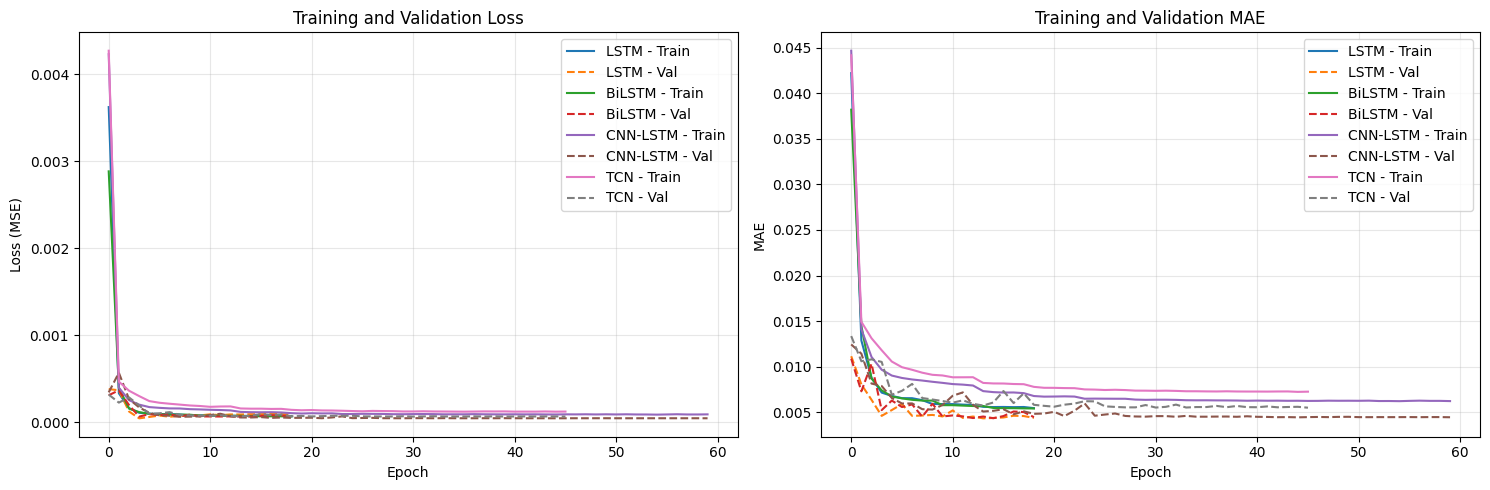

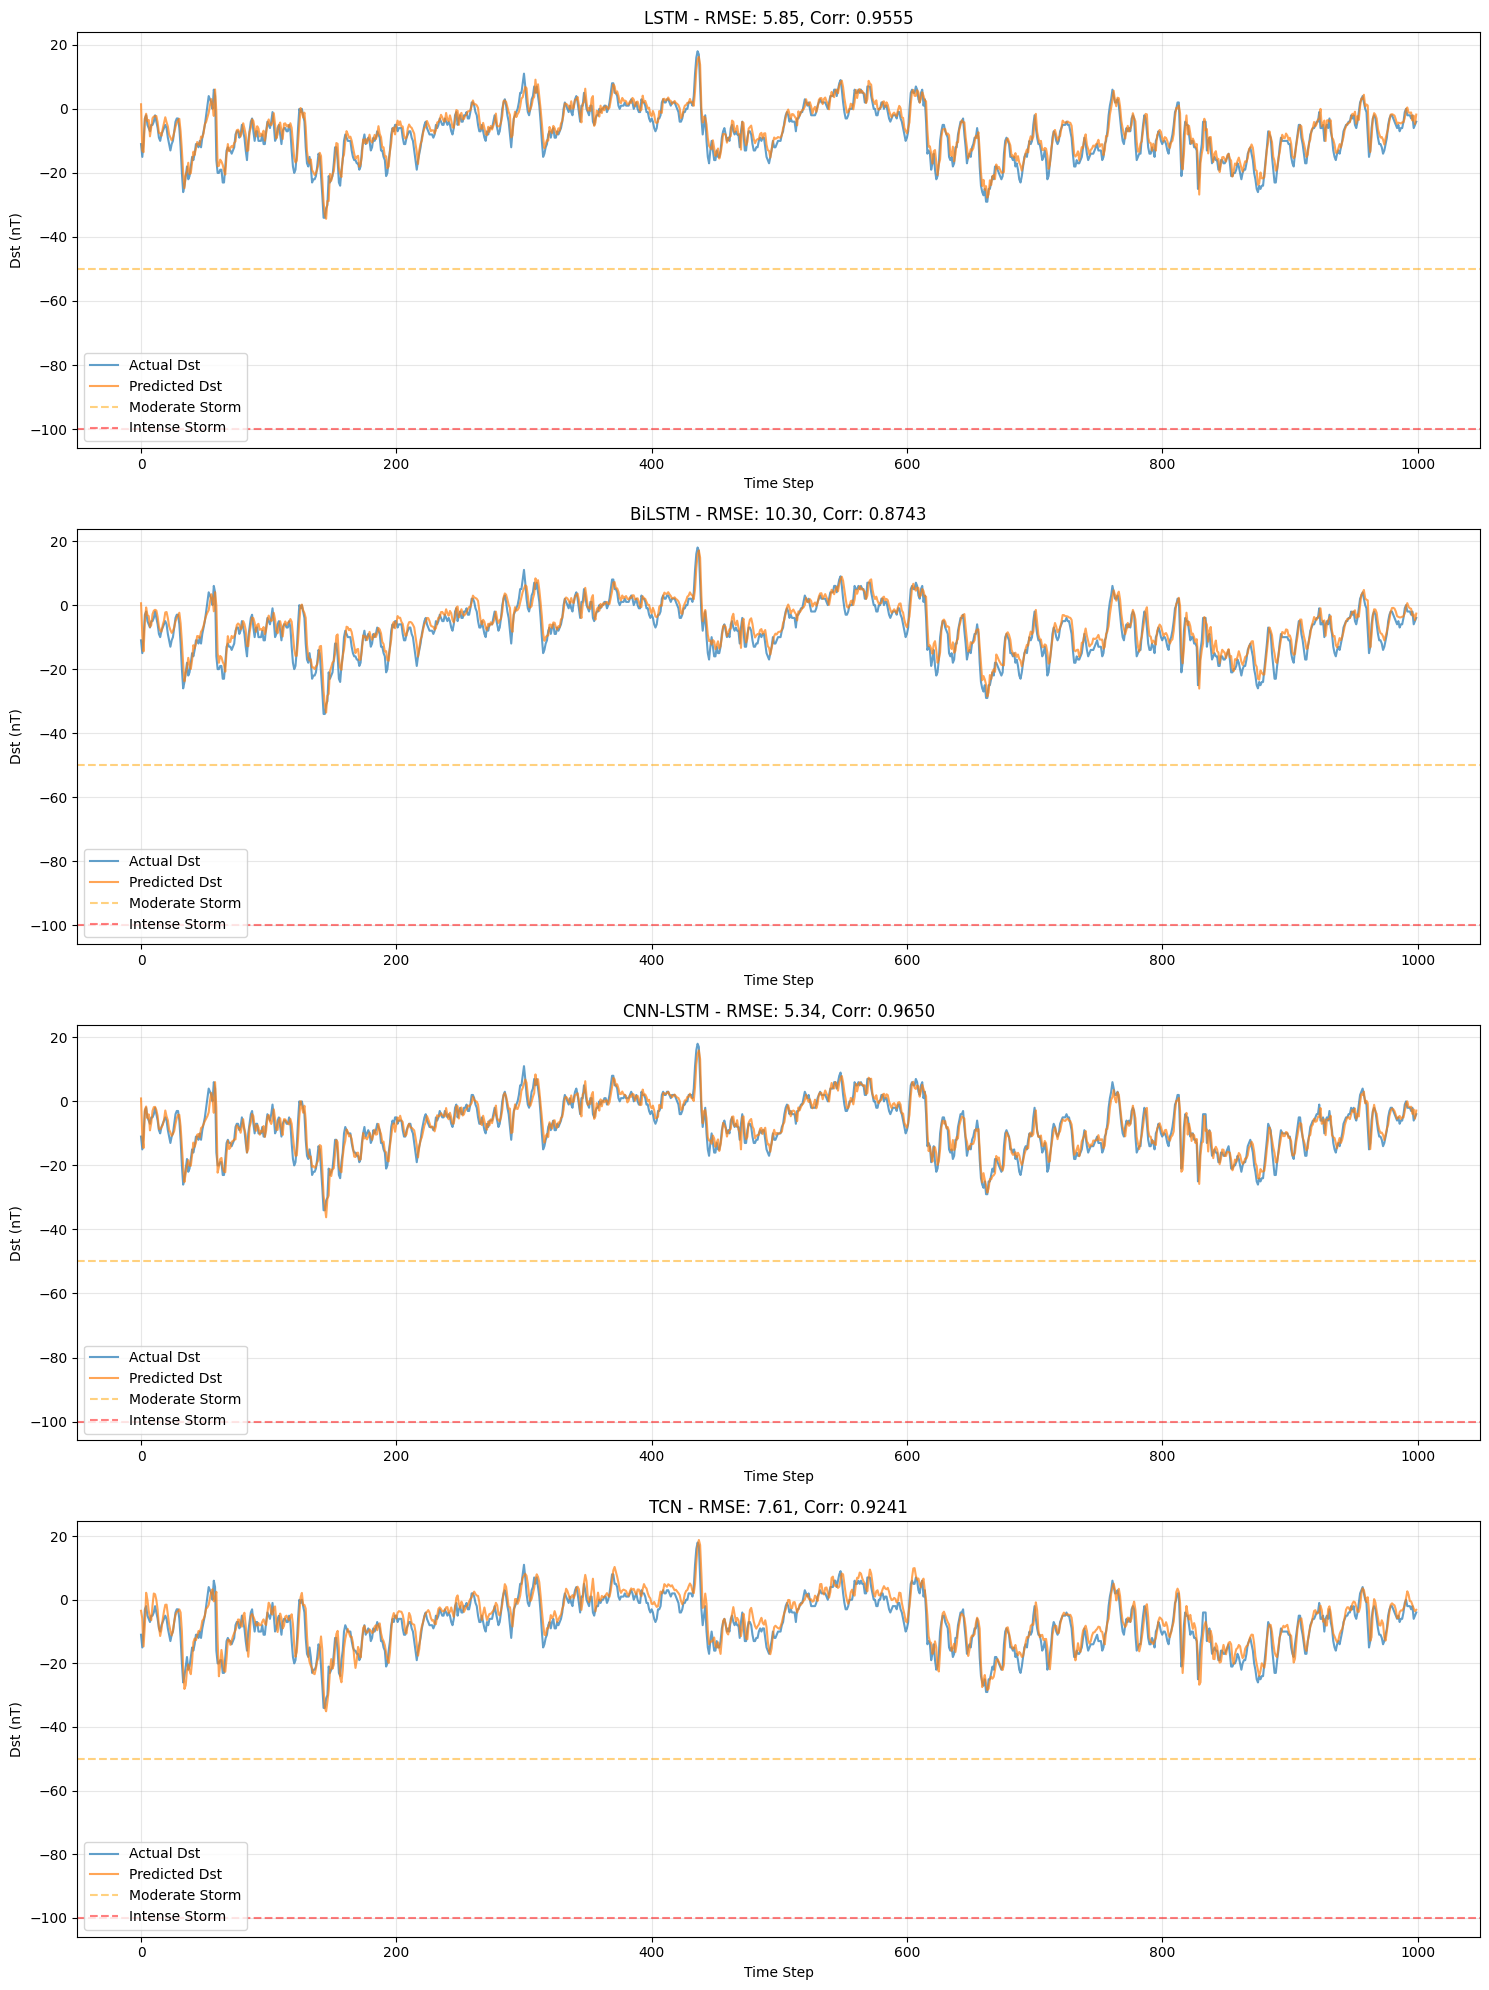

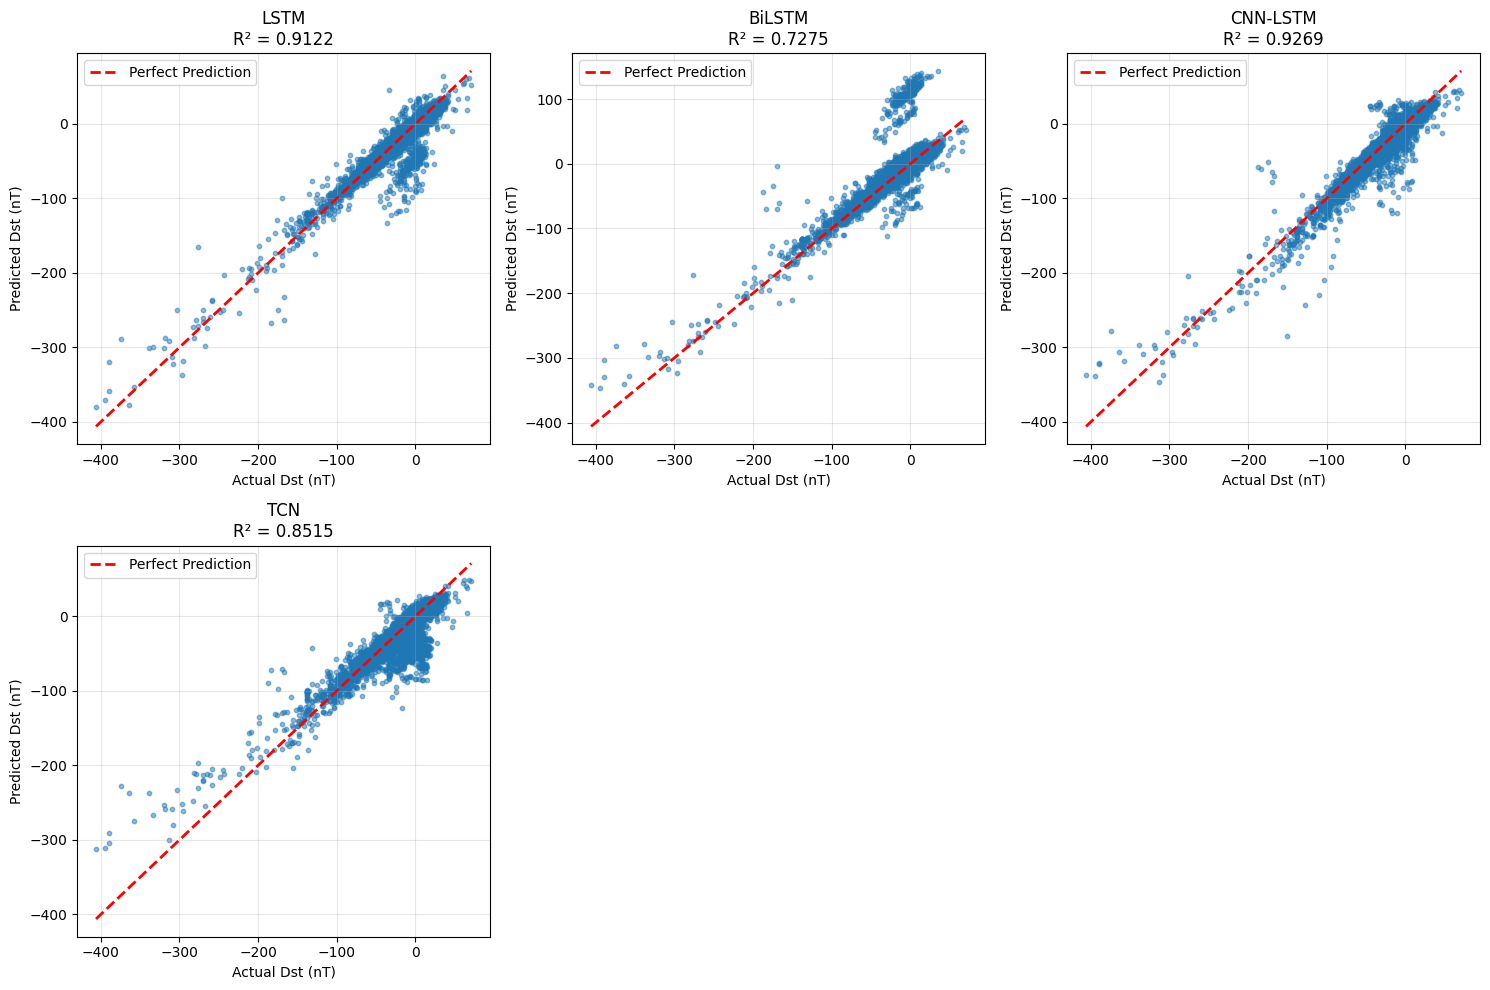

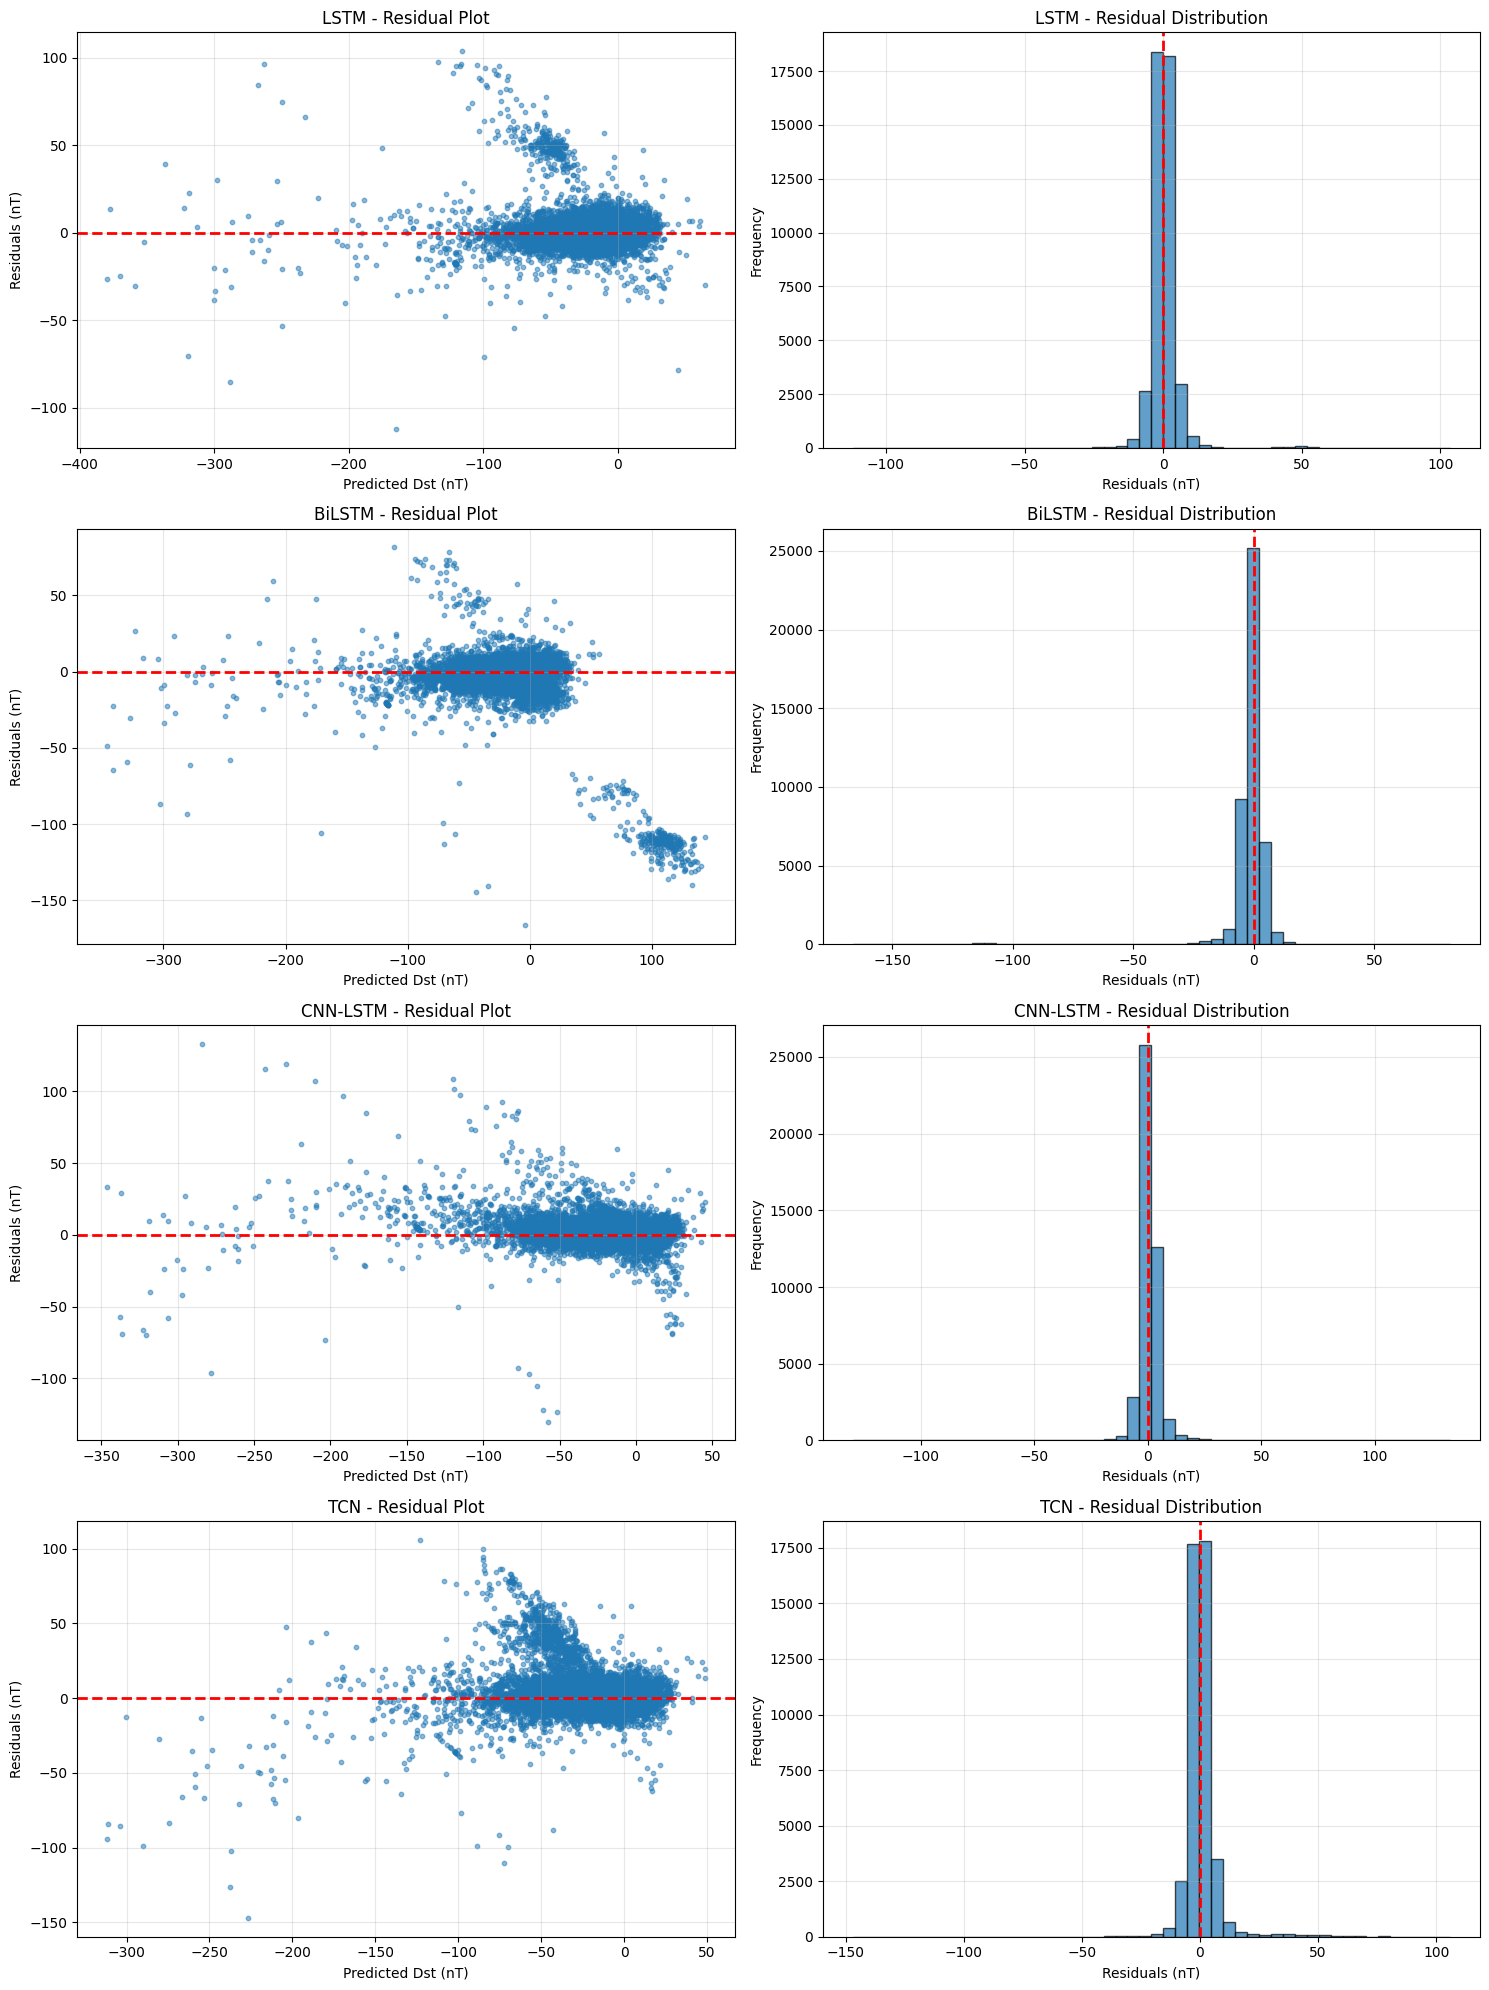


MODEL COMPARISON
   Model RMSE (nT) MAE (nT)     R² Correlation     PE
    LSTM    5.8495   2.9019 0.9122      0.9555 0.9288
  BiLSTM   10.3027   3.7351 0.7275      0.8743 0.7791
CNN-LSTM    5.3373   2.8364 0.9269      0.9650 0.9407
     TCN    7.6063   3.8380 0.8515      0.9241 0.8796

STORM CLASSIFICATION ANALYSIS

Accuracy: 0.9694

Classification Report:
              precision    recall  f1-score   support

     Intense       0.72      0.86      0.79       185
       Minor       0.74      0.79      0.76      2496
    Moderate       0.79      0.83      0.81      1054
       Quiet       0.99      0.98      0.99     40054
 Super Storm       0.79      0.95      0.86        43

    accuracy                           0.97     43832
   macro avg       0.81      0.88      0.84     43832
weighted avg       0.97      0.97      0.97     43832


Confusion Matrix:
[[  159     0    15     0    11]
 [    2  1968   178   348     0]
 [   53   121   880     0     0]
 [    4   566    41 39443     0]

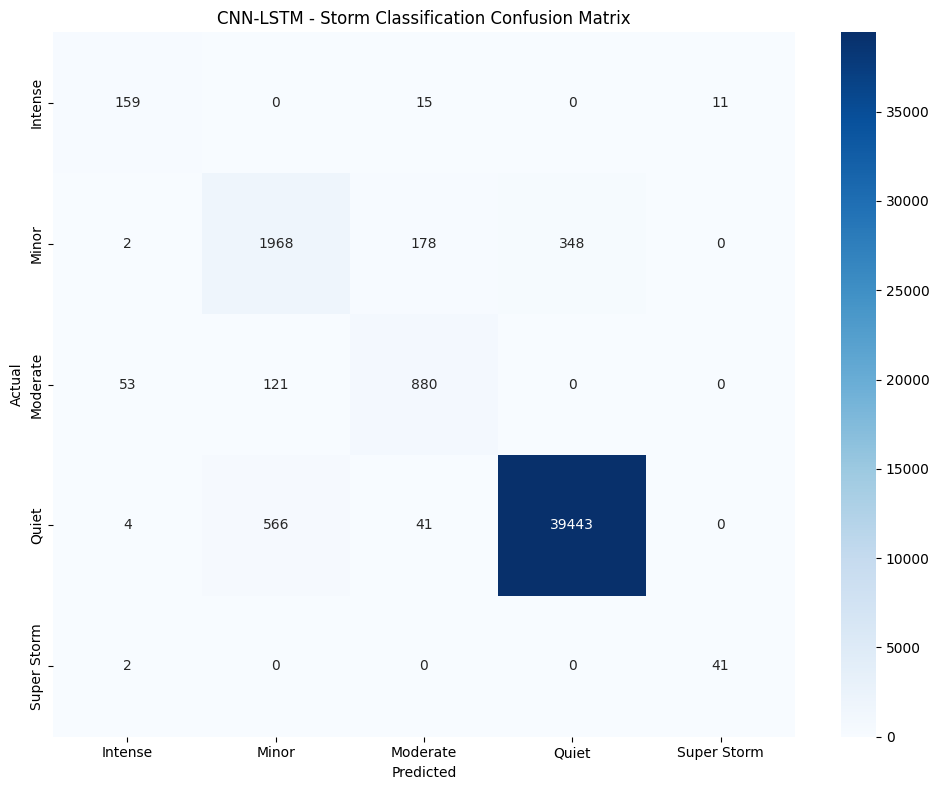


All results saved to Google Drive
Best performing model: CNN-LSTM
Best RMSE: 5.3373 nT


In [ ]:
if __name__ == "__main__":
  predictions_dict, comparison_df = main()

In [ ]:
"""
Geomagnetic Storm Prediction using Deep Learning

Author: Prajwal Bhandari
Date: January 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
!pip install tensorflow
!pip install keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                      Conv1D, MaxPooling1D, Flatten, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


In [ ]:
# -----------------------------
# 1. DATA LOADING AND PREPROCESSING
# -----------------------------

class DataPreprocessor:
    """Handles all data preprocessing operations"""

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None
        self.scaler = MinMaxScaler()
        self.missing_values_map = {
            'B': 9999.99,
            'Bx': 9999.99,
            'By': 9999.99,
            'Bz': 9999.99,
            'Vt': 99999.9,
            'FP': 999.99,
            'Kpt': 9.99,
            'AE': 9999.99
        }

    def load_data(self):
        self.df = pd.read_csv(self.filepath)
        print(f"Dataset Shape: {self.df.shape}")
        print(f"\nColumns: {list(self.df.columns)}")
        print(f"\nFirst few rows:\n{self.df.head()}")

        return self

    def handle_missing_values(self):
        # Replace placeholder values
        for col, missing_val in self.missing_values_map.items():
            if col in self.df.columns:
                count_before = (self.df[col] == missing_val).sum()
                self.df[col] = self.df[col].replace(missing_val, np.nan)
                print(f"{col}: Replaced {count_before} placeholder values")

        # Display missing value statistics
        missing_stats = self.df.isnull().sum().sort_values(ascending=False)
        missing_pct = (missing_stats / len(self.df) * 100).round(2)

        print(f"\nMissing Values Summary:")
        for col in missing_stats[missing_stats > 0].index:
            print(f"  {col}: {missing_stats[col]} ({missing_pct[col]}%)")

        return self

    def clean_data(self, target_column='Dst'):
        # Handle time column
        if 'Time' in self.df.columns:
            self.df['Time'] = pd.to_datetime(self.df['Time'], errors='coerce')
            self.df = self.df.sort_values('Time')
            self.df = self.df.drop(columns=['Time'])

        # Convert all columns to numeric
        for col in self.df.columns:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Forward fill then backward fill missing values
        self.df = self.df.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        initial_shape = self.df.shape[0]
        self.df = self.df.dropna()
        dropped_rows = initial_shape - self.df.shape[0]

        print(f"Rows dropped: {dropped_rows}")
        print(f"Final dataset shape: {self.df.shape}")
        print(f"\nData types:\n{self.df.dtypes}")

        return self

    def get_processed_data(self):
        """Return processed dataframe"""
        return self.df


# -----------------------------
# 2. SEQUENCE GENERATION
# -----------------------------

class SequenceGenerator:
    """Creates sequences for time series prediction"""

    def __init__(self, data, target_column='Dst', lookback=48):
        self.data = data
        self.target_column = target_column
        self.lookback = lookback
        self.scaler = MinMaxScaler()

    def create_sequences(self):
        """Create input-output sequences"""
        print("\n" + "=" * 70)
        print("CREATING SEQUENCES")
        print("=" * 70)

        # Scale the data
        scaled_data = self.scaler.fit_transform(self.data)
        target_index = self.data.columns.get_loc(self.target_column)

        X, y = [], []
        for i in range(len(scaled_data) - self.lookback):
            X.append(scaled_data[i:i + self.lookback])
            y.append(scaled_data[i + self.lookback, target_index])

        X = np.array(X)
        y = np.array(y)

        print(f"Sequence shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Features: {X.shape[2]}")
        print(f"Lookback: {self.lookback} hours")

        return X, y

    def split_data(self, X, y, test_size=0.2, val_size=0.15):
        # First split: train+val and test
        split_idx = int(len(X) * (1 - test_size))
        X_temp, X_test = X[:split_idx], X[split_idx:]
        y_temp, y_test = y[:split_idx], y[split_idx:]

        # Second split: train and validation
        val_split_idx = int(len(X_temp) * (1 - val_size / (1 - test_size)))
        X_train, X_val = X_temp[:val_split_idx], X_temp[val_split_idx:]
        y_train, y_val = y_temp[:val_split_idx], y_temp[val_split_idx:]

        print(f"Train set: {X_train.shape[0]} samples")
        print(f"Validation set: {X_val.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")

        return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
# -----------------------------
# 3. MODEL ARCHITECTURES
# -----------------------------

class ModelFactory:
    """Factory for creating different model architectures"""

    @staticmethod
    def build_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Standard LSTM model"""
        model = Sequential([
            LSTM(units[0], return_sequences=True, input_shape=input_shape),
            Dropout(dropout),
            LSTM(units[1]),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_bidirectional_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Bidirectional LSTM - captures patterns in both directions"""
        model = Sequential([
            Bidirectional(LSTM(units[0], return_sequences=True), input_shape=input_shape),
            Dropout(dropout),
            Bidirectional(LSTM(units[1])),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=50, dropout=0.2):
        """CNN-LSTM Hybrid - CNNs extract features, LSTM captures temporal dependencies"""
        model = Sequential([
            Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
                   input_shape=input_shape, padding='same'),
            MaxPooling1D(pool_size=2),
            Dropout(dropout),
            LSTM(lstm_units, return_sequences=True),
            Dropout(dropout),
            LSTM(lstm_units // 2),
            Dropout(dropout),
            Dense(1)
        ])
        return model


    @staticmethod
    def build_tcn(input_shape, nb_filters=64, kernel_size=3, nb_stacks=1,
                  dilations=[1, 2, 4, 8], dropout=0.2):
        """Temporal Convolutional Network - uses dilated convolutions"""
        inputs = Input(shape=input_shape)
        x = inputs

        for stack in range(nb_stacks):
            for dilation in dilations:
                # Residual block
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(x)
                conv = Dropout(dropout)(conv)
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(conv)
                conv = Dropout(dropout)(conv)

                # Match dimensions if needed
                if x.shape[-1] != nb_filters:
                    x = Conv1D(filters=nb_filters, kernel_size=1, padding='same')(x)

                x = tf.keras.layers.Add()([x, conv])
                x = tf.keras.layers.Activation('relu')(x)

        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(dropout)(x)
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

In [ ]:
# -----------------------------
# 4. TRAINING AND EVALUATION
# -----------------------------

class ModelTrainer:
    """Handles model training and evaluation"""

    def __init__(self, model_name, model, scaler):
        self.model_name = model_name
        self.model = model
        self.scaler = scaler
        self.history = None
        self.predictions = None

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )

    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32):
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
            ModelCheckpoint(f'/content/drive/MyDrive/{self.model_name}_best.h5',
                          save_best_only=True, monitor='val_loss')
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test, df, target_column='Dst'):
        # Make predictions
        y_pred_scaled = self.model.predict(X_test)

        # Inverse transform to original scale
        # Create dummy array with same features
        n_features = df.shape[1]
        target_idx = df.columns.get_loc(target_column)

        # Inverse transform predictions
        dummy_pred = np.zeros((len(y_pred_scaled), n_features))
        dummy_pred[:, target_idx] = y_pred_scaled.flatten()
        y_pred = self.scaler.inverse_transform(dummy_pred)[:, target_idx]

        # Inverse transform actual values
        dummy_actual = np.zeros((len(y_test), n_features))
        dummy_actual[:, target_idx] = y_test.flatten()
        y_actual = self.scaler.inverse_transform(dummy_actual)[:, target_idx]

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        mae = mean_absolute_error(y_actual, y_pred)
        r2 = r2_score(y_actual, y_pred)
        correlation, _ = pearsonr(y_actual, y_pred)

        # Calculate prediction efficiency (PE)
        pe = 1 - (np.sum((y_actual - y_pred) ** 2) / np.sum(y_actual ** 2))

        print(f"\nPerformance Metrics:")
        print(f"  RMSE: {rmse:.4f} nT")
        print(f"  MAE: {mae:.4f} nT")
        print(f"  R²: {r2:.4f}")
        print(f"  Correlation: {correlation:.4f}")
        print(f"  Prediction Efficiency: {pe:.4f}")

        self.predictions = {
            'actual': y_actual,
            'predicted': y_pred,
            'metrics': {
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'correlation': correlation,
                'pe': pe
            }
        }

        return self.predictions


# -----------------------------
# 5. STORM CLASSIFICATION
# -----------------------------

class StormClassifier:
    """Converts Dst predictions to storm classification"""

    @staticmethod
    def classify_Dst(Dst_values):
        """
        Classify geomagnetic storm intensity based on SYMH index

        Categories:
        - Quiet: Dst > -30 nT
        - Minor: -50 < Dst ≤ -30 nT
        - Moderate: -100 < Dst ≤ -50 nT
        - Intense: -200 < Dst ≤ -100 nT
        - Super Storm: Dst ≤ -200 nT
        """
        categories = []
        for val in Dst_values:
            if val > -30:
                categories.append('Quiet')
            elif val > -50:
                categories.append('Minor')
            elif val > -100:
                categories.append('Moderate')
            elif val > -200:
                categories.append('Intense')
            else:
                categories.append('Super Storm')
        return np.array(categories)

    @staticmethod
    def evaluate_classification(y_actual, y_pred):
        """Evaluate storm classification performance"""
        from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

        actual_classes = StormClassifier.classify_Dst(y_actual)
        pred_classes = StormClassifier.classify_Dst(y_pred)

        print("\n" + "=" * 70)
        print("STORM CLASSIFICATION ANALYSIS")
        print("=" * 70)

        print(f"\nAccuracy: {accuracy_score(actual_classes, pred_classes):.4f}")
        print(f"\nClassification Report:")
        print(classification_report(actual_classes, pred_classes))

        print(f"\nConfusion Matrix:")
        cm = confusion_matrix(actual_classes, pred_classes)
        print(cm)

        return actual_classes, pred_classes, cm


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

class Visualizer:
    """Create comprehensive visualizations"""

    @staticmethod
    def plot_training_history(histories, model_names):
        """Plot training history for all models"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        for history, name in zip(histories, model_names):
            axes[0].plot(history.history['loss'], label=f'{name} - Train')
            axes[0].plot(history.history['val_loss'], label=f'{name} - Val', linestyle='--')

        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        for history, name in zip(histories, model_names):
            if 'mae' in history.history:
                axes[1].plot(history.history['mae'], label=f'{name} - Train')
                axes[1].plot(history.history['val_mae'], label=f'{name} - Val', linestyle='--')

        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Training and Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions(predictions_dict, sample_size=1000):
        """Plot predictions vs actual for all models"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 1, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual'][:sample_size]
            predicted = pred_data['predicted'][:sample_size]
            metrics = pred_data['metrics']

            axes[idx].plot(actual, label='Actual Dst', linewidth=1.5, alpha=0.7)
            axes[idx].plot(predicted, label='Predicted Dst', linewidth=1.5, alpha=0.7)
            axes[idx].axhline(y=-50, color='orange', linestyle='--', alpha=0.5, label='Moderate Storm')
            axes[idx].axhline(y=-100, color='red', linestyle='--', alpha=0.5, label='Intense Storm')

            axes[idx].set_xlabel('Time Step')
            axes[idx].set_ylabel('Dst (nT)')
            axes[idx].set_title(f'{model_name} - RMSE: {metrics["rmse"]:.2f}, Corr: {metrics["correlation"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/predictions_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_scatter(predictions_dict):
        """Create scatter plots for all models"""
        n_models = len(predictions_dict)
        cols = 3
        rows = (n_models + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        axes = axes.flatten() if n_models > 1 else [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            metrics = pred_data['metrics']

            axes[idx].scatter(actual, predicted, alpha=0.5, s=10)
            axes[idx].plot([actual.min(), actual.max()],
                          [actual.min(), actual.max()],
                          'r--', linewidth=2, label='Perfect Prediction')

            axes[idx].set_xlabel('Actual Dst (nT)')
            axes[idx].set_ylabel('Predicted Dst (nT)')
            axes[idx].set_title(f'{model_name}\nR² = {metrics["r2"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        # Hide extra subplots
        for idx in range(n_models, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/scatter_plots.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_residuals(predictions_dict):
        """Plot residual analysis"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 2, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            residuals = actual - predicted

            # Residuals vs Predicted
            axes[idx, 0].scatter(predicted, residuals, alpha=0.5, s=10)
            axes[idx, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 0].set_xlabel('Predicted Dst (nT)')
            axes[idx, 0].set_ylabel('Residuals (nT)')
            axes[idx, 0].set_title(f'{model_name} - Residual Plot')
            axes[idx, 0].grid(True, alpha=0.3)

            # Residuals histogram
            axes[idx, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
            axes[idx, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 1].set_xlabel('Residuals (nT)')
            axes[idx, 1].set_ylabel('Frequency')
            axes[idx, 1].set_title(f'{model_name} - Residual Distribution')
            axes[idx, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/residual_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, categories, model_name):
        """Plot confusion matrix for storm classification"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=categories, yticklabels=categories)
        plt.title(f'{model_name} - Storm Classification Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'/content/drive/MyDrive/confusion_matrix_{model_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def create_comparison_table(predictions_dict):
        """Create comparison table of all models"""
        data = []
        for model_name, pred_data in predictions_dict.items():
            metrics = pred_data['metrics']
            data.append({
                'Model': model_name,
                'RMSE (nT)': f"{metrics['rmse']:.4f}",
                'MAE (nT)': f"{metrics['mae']:.4f}",
                'R²': f"{metrics['r2']:.4f}",
                'Correlation': f"{metrics['correlation']:.4f}",
                'PE': f"{metrics['pe']:.4f}"
            })

        df_results = pd.DataFrame(data)
        print("\n" + "=" * 70)
        print("MODEL COMPARISON")
        print("=" * 70)
        print(df_results.to_string(index=False))

        # Save to CSV
        df_results.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)

        return df_results

In [ ]:
# MAIN
# -----------------------------

def main():
    # 1. Load and preprocess data
    preprocessor = DataPreprocessor('S data.csv')
    preprocessor.load_data().handle_missing_values().clean_data()
    df = preprocessor.get_processed_data()

    # 2. Create sequences
    seq_gen = SequenceGenerator(df, target_column='Dst', lookback=48)
    X, y = seq_gen.create_sequences()
    X_train, X_val, X_test, y_train, y_val, y_test = seq_gen.split_data(X, y)

    # 3. Define models to train
    input_shape = (X_train.shape[1], X_train.shape[2])

    models_config = {
        'LSTM': ModelFactory.build_lstm(input_shape),
        'BiLSTM': ModelFactory.build_bidirectional_lstm(input_shape),
        'CNN-LSTM': ModelFactory.build_cnn_lstm(input_shape),
        'TCN': ModelFactory.build_tcn(input_shape)
    }

    # 4. Train and evaluate all models
    histories = []
    predictions_dict = {}

    for model_name, model in models_config.items():
        trainer = ModelTrainer(model_name, model, seq_gen.scaler)
        trainer.compile_model()

        print(f"\n{model_name} Architecture:")
        model.summary()

        history = trainer.train(X_train, y_train, X_val, y_val, epochs=200, batch_size=32)
        predictions = trainer.evaluate(X_test, y_test, df)

        histories.append(history)
        predictions_dict[model_name] = predictions

    # 5. Visualizations
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    Visualizer.plot_training_history(histories, list(models_config.keys()))
    Visualizer.plot_predictions(predictions_dict)
    Visualizer.plot_scatter(predictions_dict)
    Visualizer.plot_residuals(predictions_dict)

    # 6. Model comparison
    comparison_df = Visualizer.create_comparison_table(predictions_dict)

    # 7. Storm classification (using best model)
    best_model_name = comparison_df.loc[comparison_df['RMSE (nT)'].astype(float).idxmin(), 'Model']
    best_predictions = predictions_dict[best_model_name]

    actual_classes, pred_classes, cm = StormClassifier.evaluate_classification(
        best_predictions['actual'],
        best_predictions['predicted']
    )

    categories = ['Intense', 'Minor', 'Moderate', 'Quiet', 'Super Storm']
    Visualizer.plot_confusion_matrix(cm, categories, best_model_name)

    print(f"\nAll results saved to Google Drive")
    print(f"Best performing model: {best_model_name}")
    print(f"Best RMSE: {predictions_dict[best_model_name]['metrics']['rmse']:.4f} nT")

    return predictions_dict, comparison_df

Dataset Shape: (99474, 12)

Columns: ['YEAR', 'DOY', 'HR', 'B', 'Bx', 'By', 'Bz', 'Vt', 'FP', 'Kp', 'Dst', 'AE']

First few rows:
   YEAR DOY HR      B     Bx     By     Bz      Vt     FP    Kp   Dst     AE
0  1990   1  0  999.9  999.9  999.9  999.9  9999.0  99.99  20.0 -45.0   54.0
1  1990   1  1  999.9  999.9  999.9  999.9  9999.0  99.99  20.0 -46.0   44.0
2  1990   1  2  999.9  999.9  999.9  999.9  9999.0  99.99  20.0 -44.0   35.0
3  1990   1  3  999.9  999.9  999.9  999.9  9999.0  99.99  30.0 -43.0   66.0
4  1990   1  4  999.9  999.9  999.9  999.9  9999.0  99.99  30.0 -47.0  152.0
B: Replaced 0 placeholder values
Bx: Replaced 0 placeholder values
By: Replaced 0 placeholder values
Bz: Replaced 0 placeholder values
Vt: Replaced 0 placeholder values
FP: Replaced 0 placeholder values
AE: Replaced 0 placeholder values

Missing Values Summary:
  FP: 1 (0.0%)
  Vt: 1 (0.0%)
  Bz: 1 (0.0%)
  By: 1 (0.0%)
  Dst: 1 (0.0%)
  Kp: 1 (0.0%)
  AE: 1 (0.0%)
Rows dropped: 0
Final dataset shape: (99

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,161 (125.63 KB)

 Trainable params: 32,161 (125.63 KB)

...

2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.3077e-04 - mae: 0.0104 - val_loss: 3.0450e-04 - val_mae: 0.0100 - learning_rate: 2.5000e-04
Epoch 19/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.3071e-04 - mae: 0.0104 - val_loss: 3.1132e-04 - val_mae: 0.0098 - learning_rate: 2.5000e-04
Epoch 20/200
2017/2020 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2872e-04 - mae: 0.0103

2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.3414e-04 - mae: 0.0104 - val_loss: 2.8461e-04 - val_mae: 0.0096 - learning_rate: 2.5000e-04
Epoch 21/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.2542e-04 - mae: 0.0103 - val_loss: 2.9078e-04 - val_mae: 0.0097 - learning_rate: 2.5000e-04
Epoch 22/200
2014/2020 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2867e-04 - mae: 0.0103

2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.2487e-04 - mae: 0.0103 - val_loss: 2.5209e-04 - val_mae: 0.0094 - learning_rate: 2.5000e-04
Epoch 23/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.2347e-04 - mae: 0.0103 - val_loss: 3.0777e-04 - val_mae: 0.0097 - learning_rate: 2.5000e-04
Epoch 24/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.2414e-04 - mae: 0.0103 - val_loss: 2.5904e-04 - val_mae: 0.0092 - learning_rate: 2.5000e-04
Epoch 25/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.2207e-04 - mae: 0.0102 - val_loss: 2.6280e-04 - val_mae: 0.0095 - learning_rate: 2.5000e-04
Epoch 26/200
2005/2020 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0828e-04 - mae: 0.0099

2020/2020 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 2.0641e-04 - mae: 0.0099 - val_loss: 2.4674e-04 - val_mae: 0.0089 - learning_rate: 1.2500e-04
Epoch 27/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.1302e-04 - mae: 0.0099 - val_loss: 2.6744e-04 - val_mae: 0.0095 - learning_rate: 1.2500e-04
Epoch 28/200
2015/2020 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1119e-04 - mae: 0.0099

2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0967e-04 - mae: 0.0099 - val_loss: 2.3740e-04 - val_mae: 0.0089 - learning_rate: 1.2500e-04
Epoch 29/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0999e-04 - mae: 0.0099 - val_loss: 2.5183e-04 - val_mae: 0.0093 - learning_rate: 1.2500e-04
Epoch 30/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0568e-04 - mae: 0.0098 - val_loss: 2.6700e-04 - val_mae: 0.0095 - learning_rate: 1.2500e-04
Epoch 31/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0251e-04 - mae: 0.0097 - val_loss: 2.5180e-04 - val_mae: 0.0092 - learning_rate: 6.2500e-05
Epoch 32/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0407e-04 - mae: 0.0097 - val_loss: 2.6808e-04 - val_mae: 0.0093 - learning_rate: 6.2500e-05
Epoch 33/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2.0692e-04 - mae: 0.0098 - val_loss: 2.4886e-04 - val_mae: 0.0090 - learning_rate: 6.2500e-05
Epoch 34/200
2020/2020 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 2

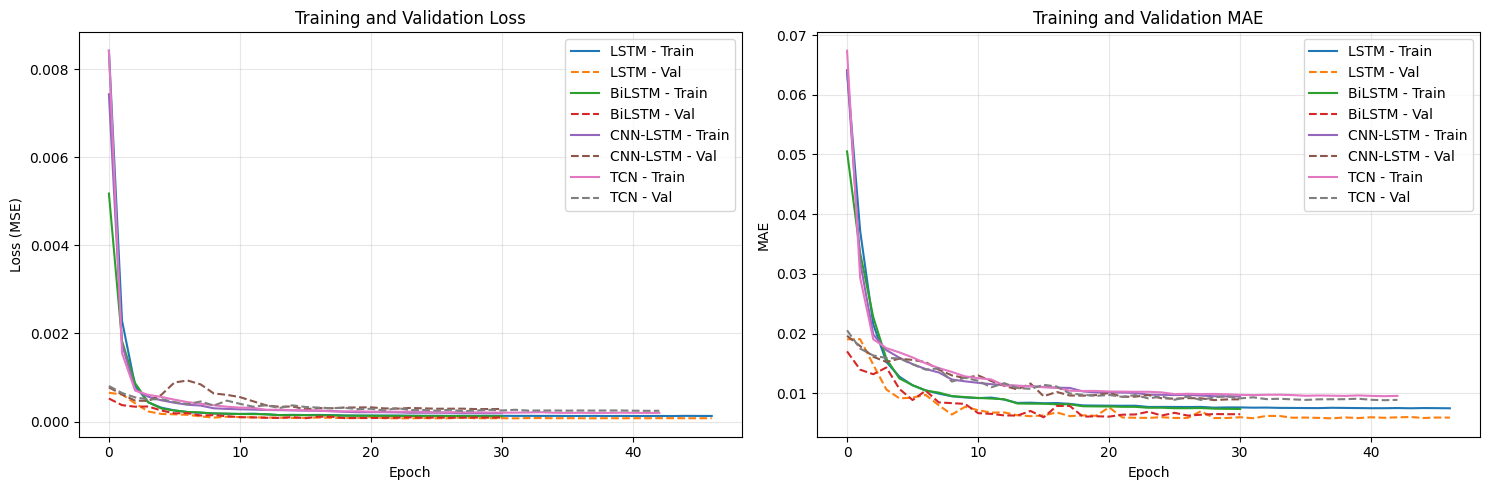

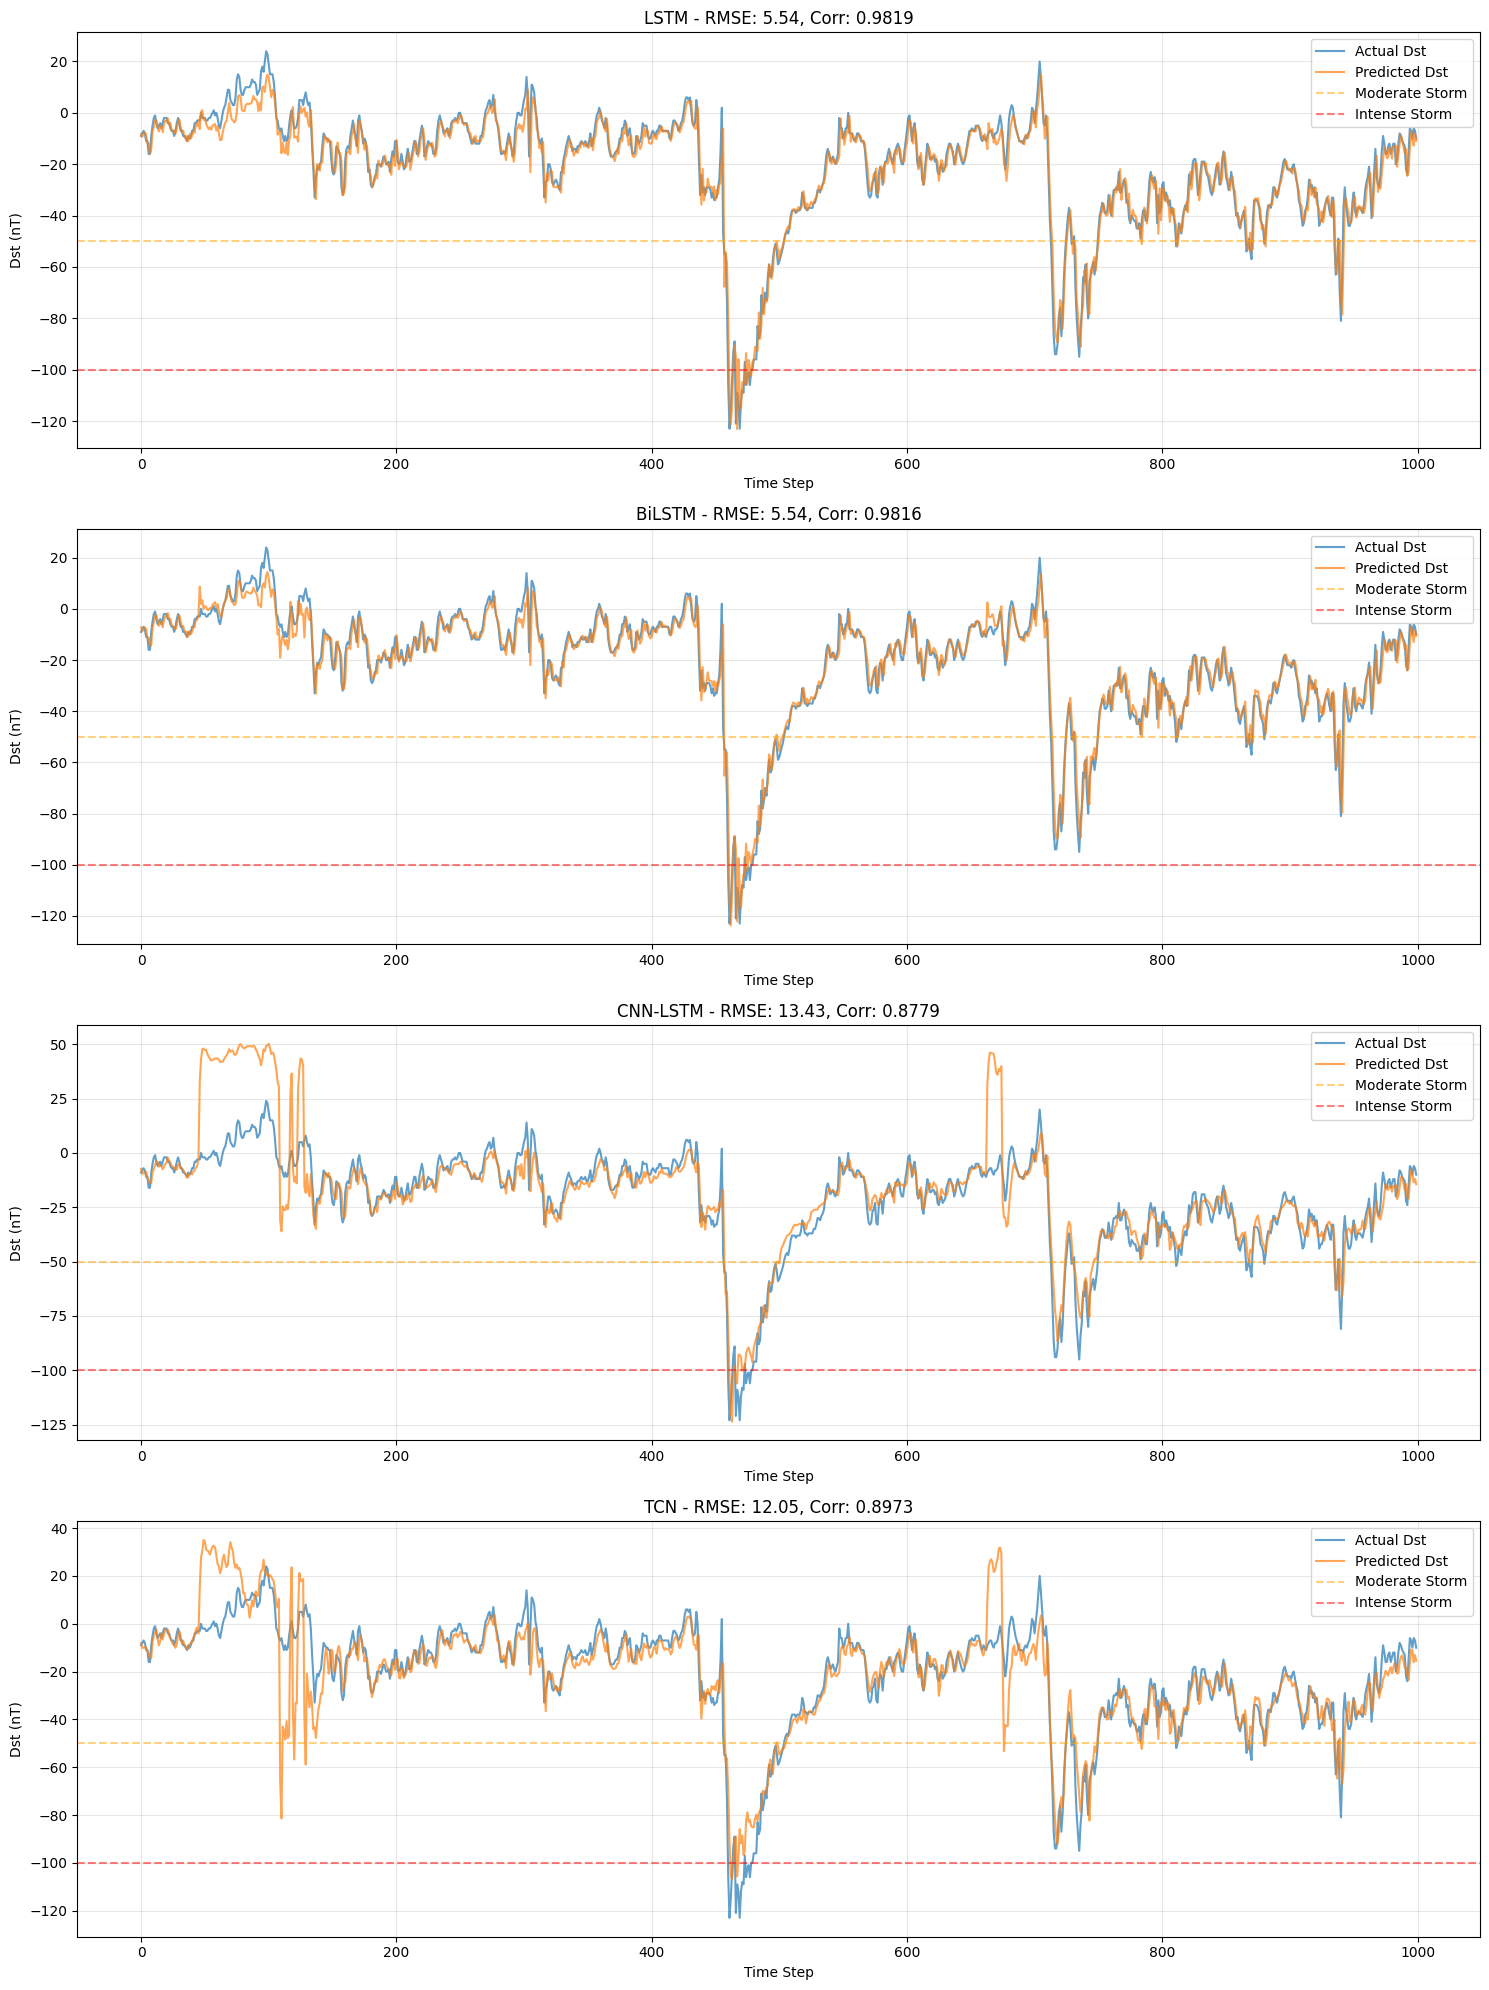

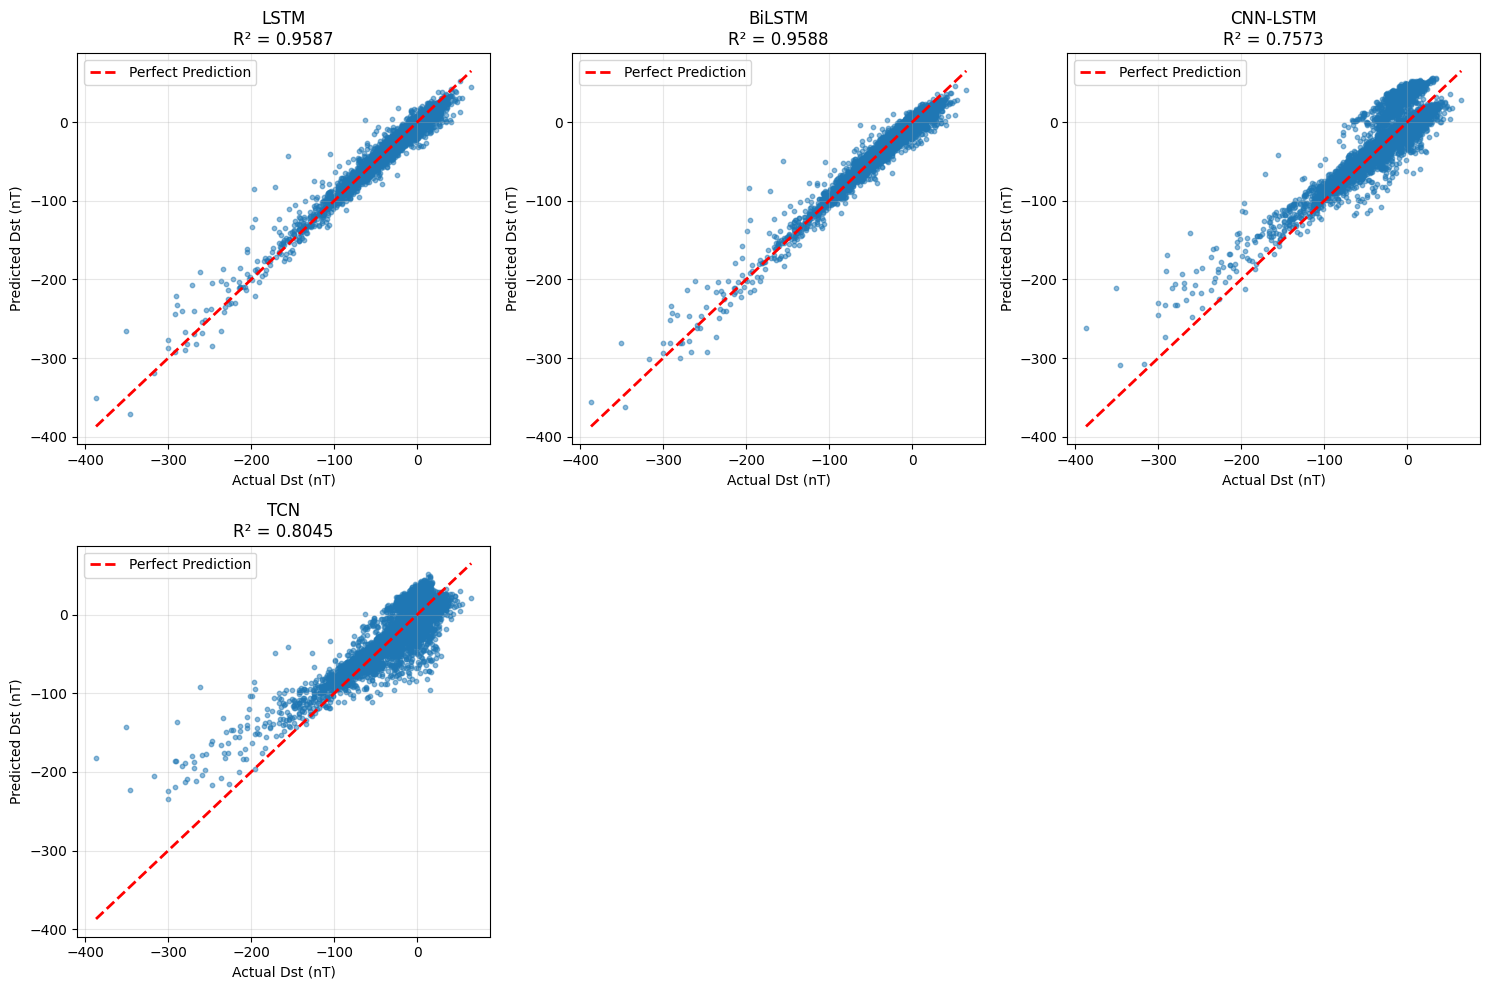

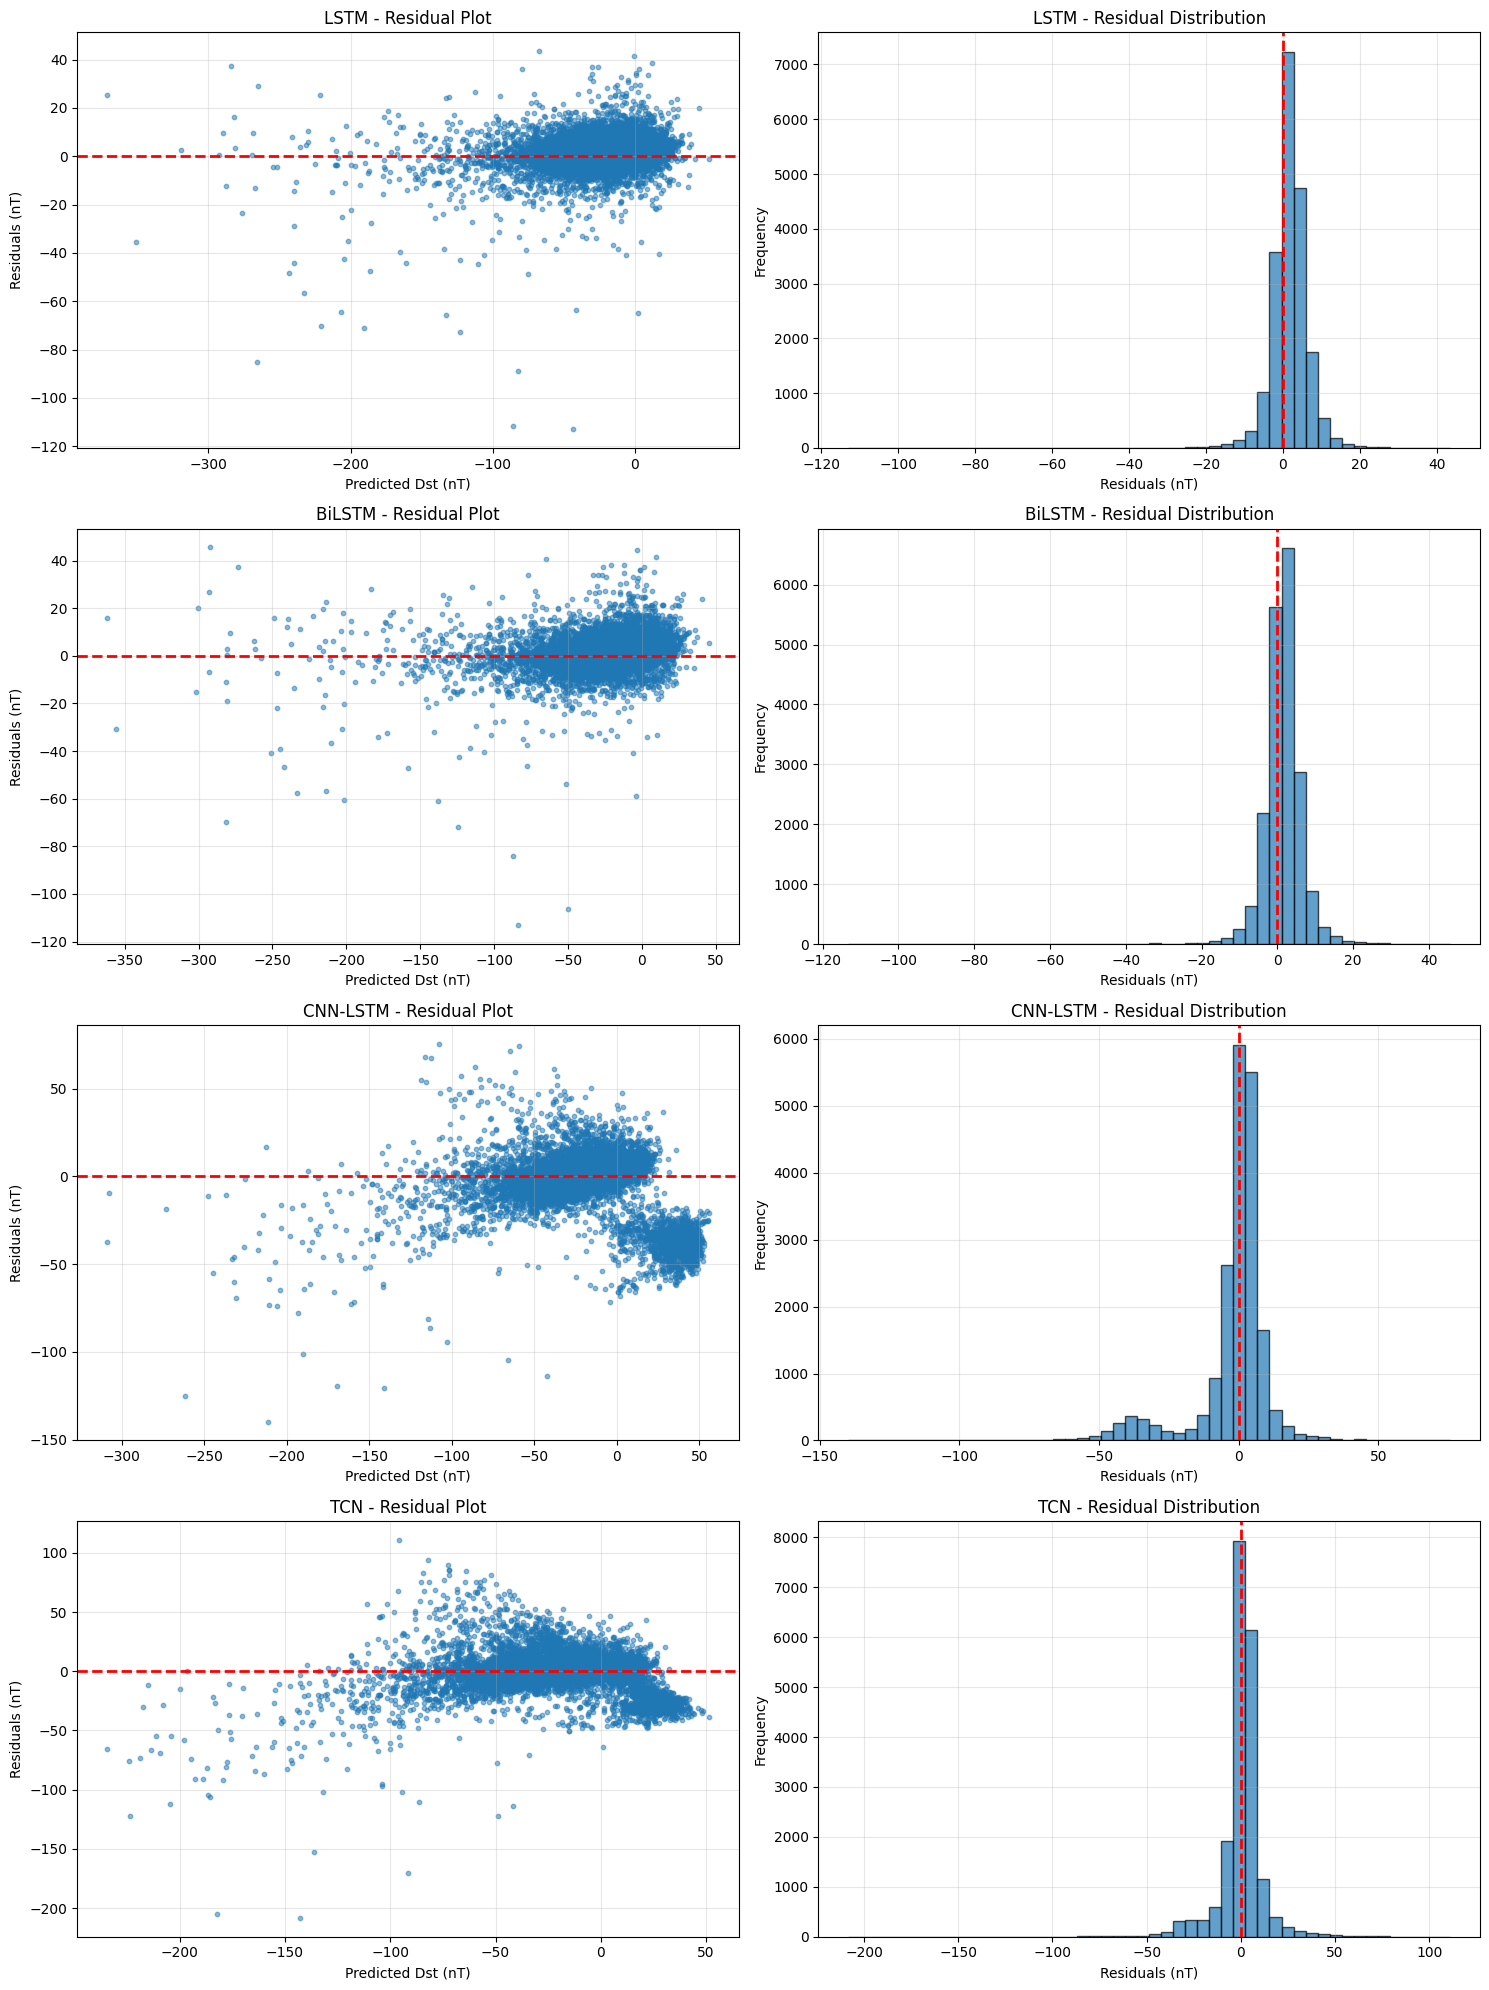


MODEL COMPARISON
   Model RMSE (nT) MAE (nT)     R² Correlation     PE
    LSTM    5.5408   3.6597 0.9587      0.9819 0.9693
  BiLSTM    5.5360   3.6791 0.9588      0.9816 0.9693
CNN-LSTM   13.4320   7.7124 0.7573      0.8779 0.8194
     TCN   12.0534   6.9061 0.8045      0.8973 0.8546

STORM CLASSIFICATION ANALYSIS

Accuracy: 0.9445

Classification Report:
              precision    recall  f1-score   support

     Intense       0.92      0.80      0.86       255
       Minor       0.79      0.80      0.80      2498
    Moderate       0.87      0.83      0.85      1180
       Quiet       0.98      0.98      0.98     15902
 Super Storm       0.90      0.92      0.91        51

    accuracy                           0.94     19886
   macro avg       0.89      0.87      0.88     19886
weighted avg       0.94      0.94      0.94     19886


Confusion Matrix:
[[  205     1    44     0     5]
 [    0  2005   103   390     0]
 [   13   182   980     5     0]
 [    0   354     2 15546     0]

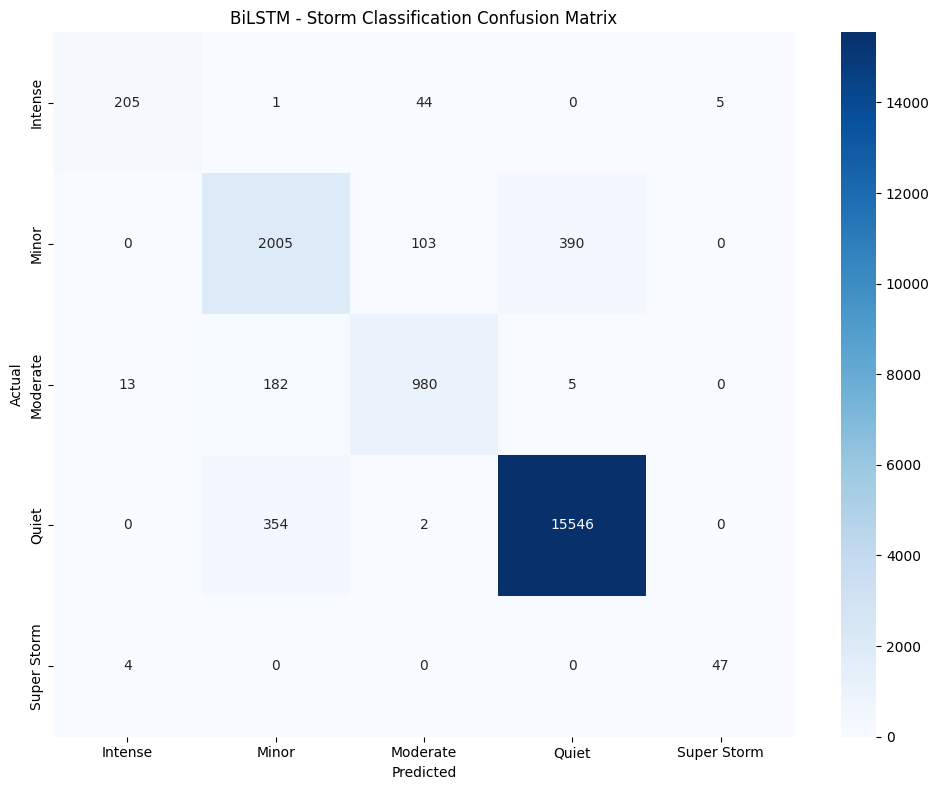


All results saved to Google Drive
Best performing model: BiLSTM
Best RMSE: 5.5360 nT


In [ ]:
if __name__ == "__main__":
  predictions_dict, comparison_df = main()